# Antibiotic Resistance Predictor — XGBoost Training Pipeline

This notebook builds a **binary classification model** to predict whether a bacterial pathogen is **Resistant (1)** or **Susceptible (0)** to a specific antibiotic, using patient demographics, clinical history, and engineered risk features.

**Architecture**: XGBoost Classifier with class-imbalance handling (`scale_pos_weight`), wrapped inside a scikit-learn `Pipeline` with a `ColumnTransformer` preprocessor.

**Target Antibiotic**: Configurable via the `TARGET` variable. Currently set to **GEN (Gentamicin)** — an aminoglycoside with ~20% baseline resistance in the dataset, making it a challenging minority-class prediction task.

**Key Improvement Over Previous Pipeline**: Uses **F2-score threshold optimization** instead of the flawed F1 ≥ 0.40 floor constraint. The F2 score weights recall 4× higher than precision, which is critical in clinical settings where **missing a resistant pathogen (false negative) is far more dangerous** than a false alarm.

---

## 1. Imports

In [31]:
# ============================================================
# Core Libraries
# ============================================================
import pandas as pd
import numpy as np
import json
import joblib
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="muted",
    font_scale=1.1
)

# ============================================================
# Scikit-learn: Preprocessing & Model Selection
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# Scikit-learn: Evaluation Metrics
# ============================================================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)

# ============================================================
# XGBoost
# ============================================================
from xgboost import XGBClassifier

print("All imports loaded successfully.")

All imports loaded successfully.


---

## 2. Load Dataset

Load the cleaned dataset (`cleaned_output_v2.csv`) produced by the data cleaning and feature generation pipeline. This file contains:
- 7 original clinical features
- 15 binary antibiotic resistance targets (R=1, S=0, NaN=missing)

Engineered features (Age_Group, Comorbidity_Score, etc.) will be re-derived in Section 4 to keep this notebook self-contained.

In [33]:
# ============================================================
# CONFIGURATION — Change TARGET to retrain for a different
# antibiotic. The rest of the notebook adapts automatically.
# ============================================================
TARGET = "AMX/AMP"

# All 15 antibiotics available in the dataset:
ALL_ANTIBIOTICS = [
    "AMX/AMP", "AMC", "CZ", "FOX", "CTX/CRO",
    "IPM", "GEN", "AN", "Acide nalidixique",
    "ofx", "CIP", "C", "Co-trimoxazole",
    "Furanes", "colistine"
]

print(f"Target antibiotic: {TARGET}")

Target antibiotic: AMX/AMP


In [34]:
# ============================================================
# Load the dataset
# ============================================================
df = pd.read_csv("cleaned_output_v2.csv")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print()
df.head()

Dataset shape: (9957, 23)
Rows: 9,957  |  Columns: 23



,ID,Age,Gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,...,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
0,S290,37.0,F,Escherichia coli,No,No,No,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,S291,29.0,F,Morganella morganii,Yes,No,No,3.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S292,77.0,F,Proteus mirabilis,Yes,No,No,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,S294,13.0,F,Escherichia coli,No,Yes,No,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S295,57.0,M,Escherichia coli,Yes,No,No,3.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Target Distribution for 'AMX/AMP':
  Susceptible (0): 4,061
  Resistant   (1): 5,712
  Missing    (NaN): 184



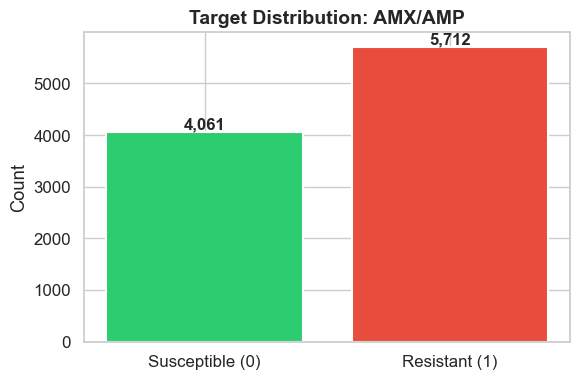

In [35]:
# ============================================================
# Target Distribution — Understanding baseline resistance rate
# is critical for interpreting model performance.
# ============================================================
target_counts = df[TARGET].value_counts(dropna=False)

print(f"Target Distribution for '{TARGET}':")
print(f"  Susceptible (0): {target_counts.get(0.0, 0):,}")
print(f"  Resistant   (1): {target_counts.get(1.0, 0):,}")
print(f"  Missing    (NaN): {df[TARGET].isna().sum():,}")
print()

# Visual distribution
fig, ax = plt.subplots(figsize=(6, 4))

colors = ["#2ecc71", "#e74c3c"]
labels = ["Susceptible (0)", "Resistant (1)"]

temp_counts = df[TARGET].dropna().value_counts().sort_index()
ax.bar(
    labels[:len(temp_counts)],
    temp_counts.values,
    color=colors[:len(temp_counts)],
    edgecolor="white",
    linewidth=1.5
)

ax.set_title(
    f"Target Distribution: {TARGET}",
    fontsize=14,
    fontweight="bold"
)
ax.set_ylabel("Count")

for i, v in enumerate(temp_counts.values):
    ax.text(
        i, v + 50,
        f"{v:,}",
        ha="center",
        fontweight="bold",
        fontsize=12
    )

plt.tight_layout()
plt.show()

---

## 3. Target Preparation

Not every patient has a lab result for every antibiotic. We remove rows where the target antibiotic result is missing (`NaN`), ensuring we only train on confirmed Resistant/Susceptible labels.

This is critical — imputing target labels would inject false signal into the model.

In [36]:
# ============================================================
# Remove rows where the target is missing
# ============================================================
temp = df[df[TARGET].notna()].copy()

total_samples   = len(temp)
resistant_count = int((temp[TARGET] == 1).sum())
suscept_count   = int((temp[TARGET] == 0).sum())

print(f"Target: {TARGET}")
print(f"{'='*40}")
print(f"Total samples:     {total_samples:,}")
print(f"Resistant  (1):    {resistant_count:,}  ({100*resistant_count/total_samples:.1f}%)")
print(f"Susceptible(0):    {suscept_count:,}  ({100*suscept_count/total_samples:.1f}%)")
print(f"Imbalance ratio:   1:{suscept_count/max(resistant_count,1):.1f}")

Target: AMX/AMP
Total samples:     9,773
Resistant  (1):    5,712  (58.4%)
Susceptible(0):    4,061  (41.6%)
Imbalance ratio:   1:0.7


---

## 4. Feature Engineering & Selection

We reconstruct all engineered features from the base columns to keep this notebook self-contained. The features are designed to capture clinical risk signals:

| Feature | Description | Clinical Rationale |
|---|---|---|
| `Age_Group` | Binned age category (Child/Young_Adult/Adult/Senior) | Seniors have weaker immune systems, higher resistance exposure |
| `Comorbidity_Score` | Sum of Diabetes + Hypertension flags | Multi-morbid patients receive more antibiotics, driving resistance |
| `Hospital_Risk` | Binary: prior hospitalization | Hospitals are hotspots for resistant organisms (nosocomial) |
| `Frequent_Infection` | Binary: ≥ 3 prior infections | Repeated infections = repeated antibiotic courses = selection pressure |
| `High_Risk_Patient` | Hospitalized AND frequent infections | Compound risk factor for multi-drug resistance |
| `Strain_Frequency` | How common the bacterial strain is in the dataset | Rare strains may have different resistance profiles |
| `Risk_Score` | Aggregate of all binary risk factors | Composite clinical risk index |

In [37]:
# ============================================================
# Engineer features from base columns
# ============================================================

# Age Group — binned age categories
temp["Age_Group"] = pd.cut(
    temp["Age"],
    bins=[0, 18, 40, 60, 120],
    labels=["Child", "Young_Adult", "Adult", "Senior"]
)

# Comorbidity Score — number of chronic conditions
temp["Comorbidity_Score"] = (
    (temp["Diabetes"] == "Yes").astype(int)
    + (temp["Hypertension"] == "Yes").astype(int)
)

# Hospital Risk — binary flag for prior hospitalization
temp["Hospital_Risk"] = (
    temp["Hospital_before"] == "Yes"
).astype(int)

# Frequent Infection — patients with >= 3 prior infections
temp["Frequent_Infection"] = (
    temp["Infection_Freq"] >= 3
).astype(int)

# High Risk Patient — hospitalized AND frequent infections
temp["High_Risk_Patient"] = (
    (temp["Hospital_before"] == "Yes")
    & (temp["Infection_Freq"] >= 3)
).astype(int)

# Strain Frequency — how common the pathogen is
strain_freq = temp["Souches"].value_counts()
temp["Strain_Frequency"] = temp["Souches"].map(strain_freq)

# Risk Score — composite clinical risk index
temp["Risk_Score"] = (
    (temp["Diabetes"] == "Yes").astype(int)
    + (temp["Hypertension"] == "Yes").astype(int)
    + (temp["Hospital_before"] == "Yes").astype(int)
    + (temp["Infection_Freq"] >= 3).astype(int)
)

print("Engineered features created successfully.")
print(f"Working dataset shape: {temp.shape}")

Engineered features created successfully.
Working dataset shape: (9773, 30)


In [38]:
# ============================================================
# Define feature set and create X, y
# ============================================================
features = [
    "Age",
    "Gender",
    "Souches",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Infection_Freq",
    "Age_Group",
    "Comorbidity_Score",
    "Hospital_Risk",
    "Frequent_Infection",
    "High_Risk_Patient",
    "Strain_Frequency",
    "Risk_Score"
]

X = temp[features].copy()
y = temp[TARGET].astype(int).copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y distribution:\n{y.value_counts().to_string()}")

X shape: (9773, 14)
y shape: (9773,)
y distribution:
AMX/AMP
1    5712
0    4061


---

## 5. Train/Test Split

We use stratified splitting to preserve the class distribution in both train and test sets. This is especially important for imbalanced targets like GEN (~20% positive rate).

In [39]:
# ============================================================
# Stratified train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

print(f"Training set:  X={X_train.shape}  y={y_train.shape}")
print(f"Test set:      X={X_test.shape}   y={y_test.shape}")
print()
print(f"Train class distribution:")
print(f"  Susceptible (0): {(y_train == 0).sum():,}  ({100*(y_train==0).mean():.1f}%)")
print(f"  Resistant   (1): {(y_train == 1).sum():,}  ({100*(y_train==1).mean():.1f}%)")
print()
print(f"Test class distribution:")
print(f"  Susceptible (0): {(y_test == 0).sum():,}  ({100*(y_test==0).mean():.1f}%)")
print(f"  Resistant   (1): {(y_test == 1).sum():,}  ({100*(y_test==1).mean():.1f}%)")

Training set:  X=(7818, 14)  y=(7818,)
Test set:      X=(1955, 14)   y=(1955,)

Train class distribution:
  Susceptible (0): 3,249  (41.6%)
  Resistant   (1): 4,569  (58.4%)

Test class distribution:
  Susceptible (0): 812  (41.5%)
  Resistant   (1): 1,143  (58.5%)


---

## 6. Handle Class Imbalance

For imbalanced datasets, XGBoost's `scale_pos_weight` parameter adjusts the gradient updates to give more importance to the minority class (Resistant).

**Formula**: `scale_pos_weight = negative_count / positive_count`

For GEN (~80% susceptible, ~20% resistant), this will be approximately 4.0, meaning the model treats each resistant sample as 4× more important than a susceptible one during training.

In [40]:
# ============================================================
# Calculate scale_pos_weight for class imbalance
# ============================================================
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print(f"Negative (Susceptible): {negative_count:,}")
print(f"Positive (Resistant):   {positive_count:,}")
print(f"scale_pos_weight:       {scale_pos_weight:.4f}")
print()
print(f"Interpretation: Each resistant sample will be weighted")
print(f"{scale_pos_weight:.1f}x more than a susceptible sample during training.")

Negative (Susceptible): 3,249
Positive (Resistant):   4,569
scale_pos_weight:       0.7111

Interpretation: Each resistant sample will be weighted
0.7x more than a susceptible sample during training.


---

## 7. Preprocessing Pipeline

We build a `ColumnTransformer` that handles numerical and categorical features separately:

- **Numerical**: `SimpleImputer(strategy="median")` fills missing values with the column median. No scaling is applied because XGBoost is a tree-based model that is invariant to feature magnitude.
- **Categorical**: `SimpleImputer(strategy="most_frequent")` fills missing values, then `OneHotEncoder(handle_unknown="ignore")` creates binary indicator columns. The `handle_unknown="ignore"` ensures the model gracefully handles unseen categories at inference time.

In [41]:
# ============================================================
# Define numerical and categorical feature groups
# ============================================================
numerical_features = [
    "Age",
    "Infection_Freq",
    "Comorbidity_Score",
    "Strain_Frequency",
    "Risk_Score"
]

categorical_features = [
    "Gender",
    "Souches",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Age_Group"
]

# Binary features that are already numeric (0/1)
# These are included in numerical_features or handled as-is
binary_features = [
    "Hospital_Risk",
    "Frequent_Infection",
    "High_Risk_Patient"
]

print(f"Numerical features ({len(numerical_features)}):  {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Binary features ({len(binary_features)}):      {binary_features}")

Numerical features (5):  ['Age', 'Infection_Freq', 'Comorbidity_Score', 'Strain_Frequency', 'Risk_Score']
Categorical features (6): ['Gender', 'Souches', 'Diabetes', 'Hypertension', 'Hospital_before', 'Age_Group']
Binary features (3):      ['Hospital_Risk', 'Frequent_Infection', 'High_Risk_Patient']


In [42]:
# ============================================================
# Build the ColumnTransformer preprocessor
# ============================================================

# Numerical pipeline: impute missing with median
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline: impute missing, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Binary pipeline: impute missing with median (already 0/1)
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", binary_transformer, binary_features)
    ]
)

print("Preprocessing pipeline created.")
print("  - Numerical:   SimpleImputer(median)")
print("  - Categorical: SimpleImputer(most_frequent) → OneHotEncoder")
print("  - Binary:      SimpleImputer(median) [passthrough]")

Preprocessing pipeline created.
  - Numerical:   SimpleImputer(median)
  - Categorical: SimpleImputer(most_frequent) → OneHotEncoder
  - Binary:      SimpleImputer(median) [passthrough]


---

## 8. XGBoost Model

XGBoost is chosen for its strong performance on tabular data with class imbalance. Key hyperparameters:

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 300 | Enough trees for convergence on this dataset size |
| `max_depth` | 5 | Moderate depth prevents overfitting on ~10K samples |
| `learning_rate` | 0.05 | Slow learning rate with more trees = better generalization |
| `subsample` | 0.8 | Row subsampling adds stochasticity, reduces overfitting |
| `colsample_bytree` | 0.8 | Feature subsampling per tree |
| `scale_pos_weight` | *calculated* | Addresses the ~4:1 class imbalance |
| `eval_metric` | logloss | Proper scoring rule for probability calibration |

In [43]:
# ============================================================
# Create the XGBoost classifier
# ============================================================
classifier = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost Classifier configured:")
print(f"  n_estimators:      {classifier.n_estimators}")
print(f"  max_depth:         {classifier.max_depth}")
print(f"  learning_rate:     {classifier.learning_rate}")
print(f"  subsample:         {classifier.subsample}")
print(f"  colsample_bytree:  {classifier.colsample_bytree}")
print(f"  scale_pos_weight:  {scale_pos_weight:.4f}")
print(f"  eval_metric:       {classifier.eval_metric}")

XGBoost Classifier configured:
  n_estimators:      300
  max_depth:         5
  learning_rate:     0.05
  subsample:         0.8
  colsample_bytree:  0.8
  scale_pos_weight:  0.7111
  eval_metric:       logloss


In [44]:
# ============================================================
# Assemble the full sklearn Pipeline
# ============================================================
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])

print("Full Pipeline:")
print(pipeline)

Full Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Infection_Freq',
                                                   'Comorbidity_Score',
                                                   'Strain_Frequency',
                                                   'Risk_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore')

---

## 9. Model Training

Fit the complete pipeline (preprocessing + XGBoost) on the training data.

In [45]:
# ============================================================
# Train the pipeline
# ============================================================
print(f"Training XGBoost pipeline for '{TARGET}'...")
print(f"Training samples: {len(X_train):,}")
print()

pipeline.fit(X_train, y_train)

print(f"\n{'='*50}")
print(f"  Training complete for target: {TARGET}")
print(f"{'='*50}")

Training XGBoost pipeline for 'AMX/AMP'...
Training samples: 7,818


  Training complete for target: AMX/AMP


---

## 10. Evaluation (Default Threshold = 0.50)

First, we evaluate the model using the standard 0.50 probability threshold. This serves as our **baseline** before threshold optimization.

In [46]:
# ============================================================
# Predictions at default threshold (0.50)
# ============================================================
y_pred_default = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Classification Report
print(f"Classification Report — {TARGET} (Threshold = 0.50)")
print("=" * 55)
print(
    classification_report(
        y_test, y_pred_default,
        target_names=["Susceptible", "Resistant"]
    )
)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Classification Report — AMX/AMP (Threshold = 0.50)
              precision    recall  f1-score   support

 Susceptible       0.61      0.53      0.57       812
   Resistant       0.69      0.76      0.73      1143

    accuracy                           0.66      1955
   macro avg       0.65      0.64      0.65      1955
weighted avg       0.66      0.66      0.66      1955

ROC-AUC Score: 0.6653


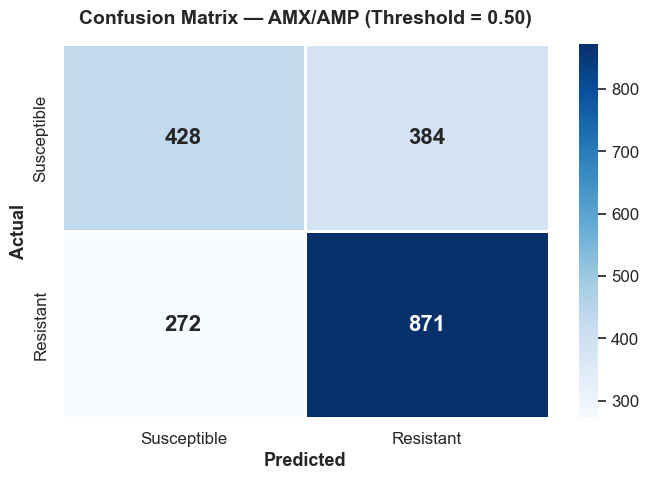


True Negatives  (correctly predicted Susceptible): 428
False Positives (incorrectly predicted Resistant):  384
False Negatives (MISSED Resistance — dangerous!):   272
True Positives  (correctly predicted Resistant):    871


In [47]:
# ============================================================
# Confusion Matrix Heatmap
# ============================================================
cm = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Susceptible", "Resistant"],
    yticklabels=["Susceptible", "Resistant"],
    annot_kws={"size": 16, "fontweight": "bold"},
    linewidths=2,
    linecolor="white",
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual", fontsize=13, fontweight="bold")
ax.set_title(
    f"Confusion Matrix — {TARGET} (Threshold = 0.50)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

# Interpret the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted Susceptible): {tn}")
print(f"False Positives (incorrectly predicted Resistant):  {fp}")
print(f"False Negatives (MISSED Resistance — dangerous!):   {fn}")
print(f"True Positives  (correctly predicted Resistant):    {tp}")

---

## 11. Probability Analysis

Understanding the **distribution of predicted probabilities** is crucial for threshold selection. If the model's probabilities are well-calibrated, we should see:
- Susceptible samples clustered near 0
- Resistant samples clustered near 1
- Separation between the two distributions

Poor separation indicates the model struggles to distinguish the classes, which is common for minority-class antibiotics.

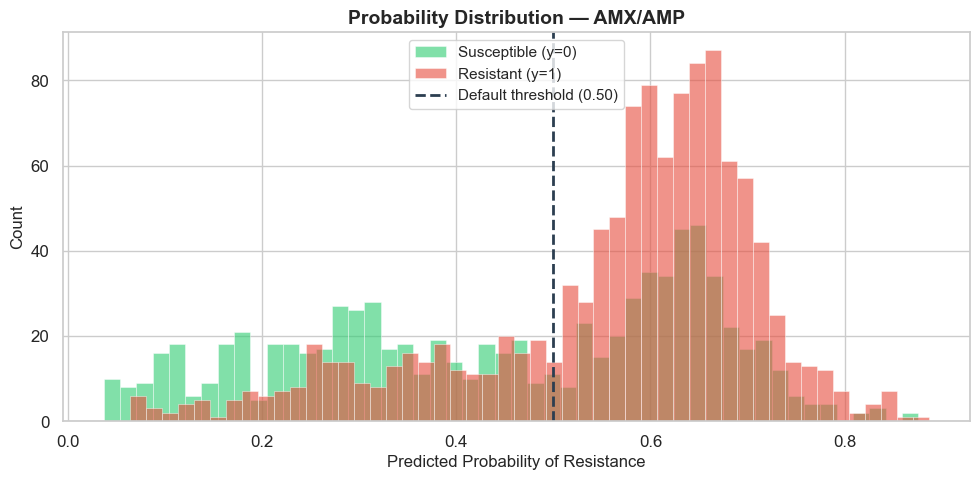

Probability statistics for 'AMX/AMP':
  Susceptible samples — mean: 0.448, median: 0.463
  Resistant samples   — mean: 0.565, median: 0.605


In [48]:
# ============================================================
# Probability Distribution Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

# Plot distribution for each class
ax.hist(
    y_proba[y_test == 0],
    bins=50,
    alpha=0.6,
    color="#2ecc71",
    label="Susceptible (y=0)",
    edgecolor="white",
    linewidth=0.5
)

ax.hist(
    y_proba[y_test == 1],
    bins=50,
    alpha=0.6,
    color="#e74c3c",
    label="Resistant (y=1)",
    edgecolor="white",
    linewidth=0.5
)

# Mark the default threshold
ax.axvline(
    x=0.50,
    color="#2c3e50",
    linestyle="--",
    linewidth=2,
    label="Default threshold (0.50)"
)

ax.set_xlabel("Predicted Probability of Resistance", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Probability Distribution — {TARGET}",
    fontsize=14,
    fontweight="bold"
)
ax.legend(fontsize=11, loc="upper center")

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Probability statistics for '{TARGET}':")
print(f"  Susceptible samples — mean: {y_proba[y_test==0].mean():.3f}, median: {np.median(y_proba[y_test==0]):.3f}")
print(f"  Resistant samples   — mean: {y_proba[y_test==1].mean():.3f}, median: {np.median(y_proba[y_test==1]):.3f}")

---

## 12. Threshold Optimization (F2 Score)

### Why F2 instead of F1?

In clinical antibiotic resistance prediction, **false negatives are far more dangerous than false positives**:

- **False Negative** (missed resistance): Patient receives an ineffective antibiotic → treatment failure, worsening infection, potential sepsis
- **False Positive** (false alarm): Patient receives a broader-spectrum antibiotic → slightly suboptimal but not harmful

The **F2 score** weights recall 4× higher than precision:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}$$

where $\beta = 2$.

We search over thresholds from 0.05 to 0.95 to find the one that maximizes F2.

In [49]:
# ============================================================
# F2-Score Threshold Search
# ============================================================
def find_best_threshold_f2(y_true, y_proba, thresholds=None):
    """
    Search for the threshold that maximizes the F2 score.
    
    F2 score heavily penalizes false negatives (missed resistance),
    which is the clinically safer optimization target.
    
    Parameters
    ----------
    y_true : array-like
        True binary labels.
    y_proba : array-like
        Predicted probabilities for the positive class.
    thresholds : array-like, optional
        Thresholds to evaluate. Default: np.arange(0.05, 0.96, 0.01)
    
    Returns
    -------
    best_threshold : float
        Threshold that maximizes F2.
    best_f2 : float
        The F2 score at the best threshold.
    results : list of dict
        All threshold evaluations.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)
    
    results = []
    best_f2 = -1
    best_threshold = 0.50
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        
        # Skip if all predictions are the same class
        if len(np.unique(y_pred)) < 2:
            f2 = 0.0
        else:
            f2 = fbeta_score(y_true, y_pred, beta=2)
        
        results.append({
            "threshold": round(thresh, 2),
            "f2": round(f2, 4)
        })
        
        if f2 > best_f2:
            best_f2 = f2
            best_threshold = round(thresh, 2)
    
    return best_threshold, best_f2, results


# Run the search
best_threshold, best_f2, threshold_results = find_best_threshold_f2(
    y_test, y_proba
)

print(f"{'='*50}")
print(f"  Threshold Optimization Results")
print(f"{'='*50}")
print(f"  Best Threshold: {best_threshold}")
print(f"  Best F2 Score:  {best_f2:.4f}")
print(f"{'='*50}")

  Threshold Optimization Results
  Best Threshold: 0.06
  Best F2 Score:  0.8771


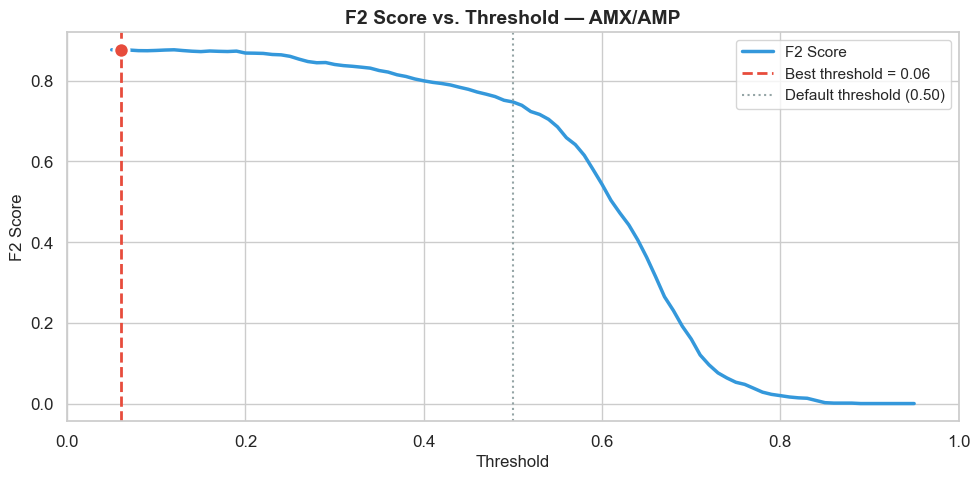

In [50]:
# ============================================================
# Visualize F2 score across thresholds
# ============================================================
results_df = pd.DataFrame(threshold_results)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    results_df["threshold"],
    results_df["f2"],
    color="#3498db",
    linewidth=2.5,
    label="F2 Score"
)

# Mark the best threshold
ax.axvline(
    x=best_threshold,
    color="#e74c3c",
    linestyle="--",
    linewidth=2,
    label=f"Best threshold = {best_threshold}"
)

ax.scatter(
    [best_threshold], [best_f2],
    color="#e74c3c",
    s=120,
    zorder=5,
    edgecolors="white",
    linewidth=2
)

# Mark default threshold for comparison
ax.axvline(
    x=0.50,
    color="#95a5a6",
    linestyle=":",
    linewidth=1.5,
    label="Default threshold (0.50)"
)

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("F2 Score", fontsize=12)
ax.set_title(
    f"F2 Score vs. Threshold — {TARGET}",
    fontsize=14,
    fontweight="bold"
)
ax.legend(fontsize=11)
ax.set_xlim(0.0, 1.0)

plt.tight_layout()
plt.show()

---

## 13. Evaluation Using Optimized Threshold

Now we compare the model's performance at the **optimized F2 threshold** against the **default 0.50 threshold**. We expect to see:
- Higher recall (fewer missed resistant cases)
- Slightly lower precision (more false alarms, which is acceptable)
- Higher F2 score (our optimization target)

In [51]:
# ============================================================
# Compare default vs optimized threshold
# ============================================================

def evaluate_at_threshold(y_true, y_proba, threshold, label=""):
    """
    Calculate key metrics at a given threshold.
    
    Returns a dict of metrics.
    """
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    }
    
    return metrics


# Evaluate at both thresholds
default_metrics  = evaluate_at_threshold(y_test, y_proba, 0.50, "Default")
optimized_metrics = evaluate_at_threshold(y_test, y_proba, best_threshold, "Optimized")

# Build comparison table
comparison = pd.DataFrame([
    default_metrics,
    optimized_metrics
], index=["Default (0.50)", f"Optimized ({best_threshold})"])

# Format as percentages for readability
comparison_display = comparison.copy()
for col in ["Precision", "Recall", "F1", "F2"]:
    comparison_display[col] = comparison_display[col].apply(lambda x: f"{x:.4f}")

print(f"\nPerformance Comparison — {TARGET}")
print("=" * 60)
print(comparison_display.to_string())
print("=" * 60)


Performance Comparison — AMX/AMP
                  Threshold Precision  Recall      F1      F2
Default (0.50)         0.50    0.6940  0.7620  0.7264  0.7474
Optimized (0.06)       0.06    0.5880  1.0000  0.7405  0.8771


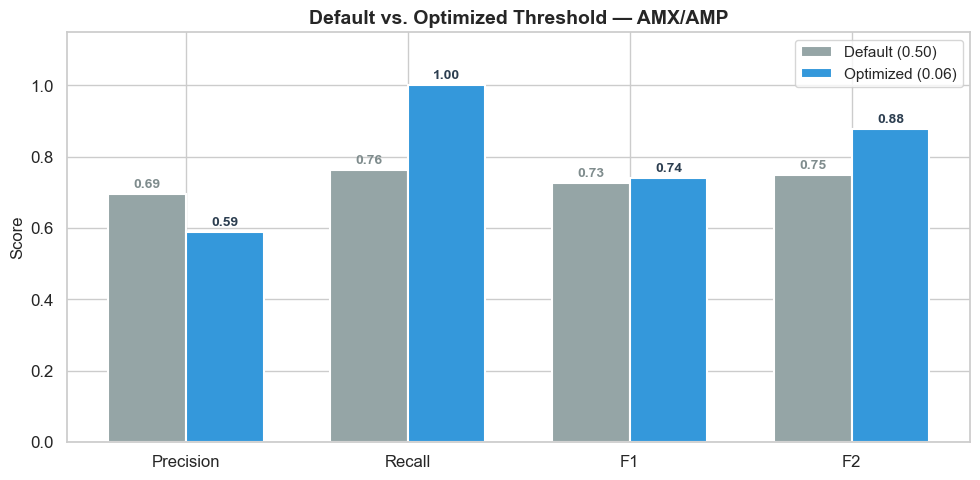

In [52]:
# ============================================================
# Visual comparison: bar chart
# ============================================================
metrics_names = ["Precision", "Recall", "F1", "F2"]

default_vals  = [default_metrics[m] for m in metrics_names]
optimized_vals = [optimized_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width/2, default_vals, width,
    label="Default (0.50)",
    color="#95a5a6",
    edgecolor="white",
    linewidth=1.5
)

bars2 = ax.bar(
    x + width/2, optimized_vals, width,
    label=f"Optimized ({best_threshold})",
    color="#3498db",
    edgecolor="white",
    linewidth=1.5
)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height + 0.01,
        f"{height:.2f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color="#7f8c8d"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height + 0.01,
        f"{height:.2f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color="#2c3e50"
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    f"Default vs. Optimized Threshold — {TARGET}",
    fontsize=14,
    fontweight="bold"
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

Classification Report — AMX/AMP (Threshold = 0.06)
              precision    recall  f1-score   support

 Susceptible       1.00      0.01      0.03       812
   Resistant       0.59      1.00      0.74      1143

    accuracy                           0.59      1955
   macro avg       0.79      0.51      0.38      1955
weighted avg       0.76      0.59      0.44      1955



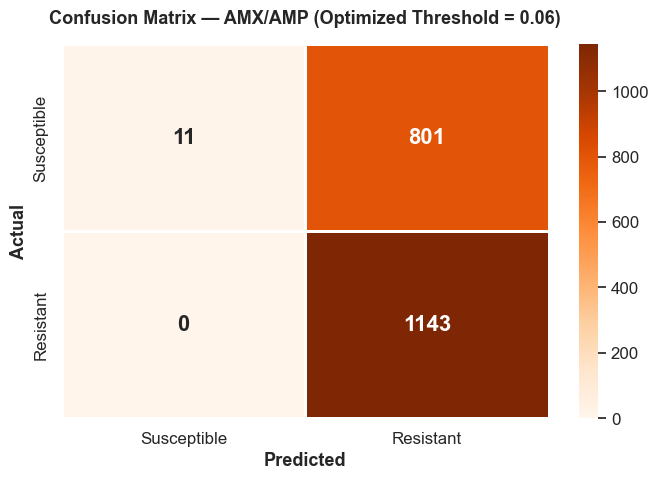


Optimized Threshold Results:
  True Negatives:  11  (correctly Susceptible)
  False Positives: 801  (false alarms — acceptable)
  False Negatives: 0  (missed resistance — REDUCED)
  True Positives:  1143  (caught resistance — INCREASED)


In [53]:
# ============================================================
# Full classification report at optimized threshold
# ============================================================
y_pred_optimized = (y_proba >= best_threshold).astype(int)

print(f"Classification Report — {TARGET} (Threshold = {best_threshold})")
print("=" * 55)
print(
    classification_report(
        y_test, y_pred_optimized,
        target_names=["Susceptible", "Resistant"]
    )
)

# Optimized confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_optimized)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Susceptible", "Resistant"],
    yticklabels=["Susceptible", "Resistant"],
    annot_kws={"size": 16, "fontweight": "bold"},
    linewidths=2,
    linecolor="white",
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual", fontsize=13, fontweight="bold")
ax.set_title(
    f"Confusion Matrix — {TARGET} (Optimized Threshold = {best_threshold})",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

# Summary
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()
print(f"\nOptimized Threshold Results:")
print(f"  True Negatives:  {tn_opt}  (correctly Susceptible)")
print(f"  False Positives: {fp_opt}  (false alarms — acceptable)")
print(f"  False Negatives: {fn_opt}  (missed resistance — REDUCED)")
print(f"  True Positives:  {tp_opt}  (caught resistance — INCREASED)")

---

## 14. Feature Importance

Extract and visualize the top 20 most important features from the trained XGBoost model. Feature importance is based on the **total gain** — the improvement in loss function that a feature provides across all splits where it's used.

This helps us understand:
- Which clinical variables drive resistance predictions
- Whether engineered features provide additional signal
- If the model is relying on clinically meaningful patterns

In [54]:
# ============================================================
# Extract feature names after preprocessing
# ============================================================

def get_feature_names(preprocessor, numerical_features, categorical_features, binary_features):
    """
    Extract feature names from a fitted ColumnTransformer.
    
    Handles OneHotEncoder feature names and preserves
    numerical/binary feature names.
    """
    feature_names = []
    
    # Numerical features (unchanged)
    feature_names.extend(numerical_features)
    
    # Categorical features (one-hot encoded)
    cat_encoder = preprocessor.named_transformers_["cat"]
    ohe = cat_encoder.named_steps["encoder"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    feature_names.extend(cat_feature_names)
    
    # Binary features (unchanged)
    feature_names.extend(binary_features)
    
    return feature_names


# Get feature names
fitted_preprocessor = pipeline.named_steps["preprocessor"]
feature_names = get_feature_names(
    fitted_preprocessor,
    numerical_features,
    categorical_features,
    binary_features
)

# Get feature importances from XGBoost
xgb_model = pipeline.named_steps["classifier"]
importances = xgb_model.feature_importances_

# Create importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(f"Total features after preprocessing: {len(feature_names)}")
print(f"\nTop 20 Features for {TARGET}:")
print(importance_df.head(20).to_string(index=False))

Total features after preprocessing: 34

Top 20 Features for AMX/AMP:
                       Feature  Importance
      Souches_Escherichia coli    0.351246
              Strain_Frequency    0.080552
 Souches_Klebsiella pneumoniae    0.069574
   Souches_Serratia marcescens    0.038626
   Souches_Morganella morganii    0.035453
   Souches_Enterobacteria spp.    0.021426
     Souches_Proteus mirabilis    0.020207
      Souches_Citrobacter spp.    0.020167
                           Age    0.018821
              Hypertension_Yes    0.017612
             Comorbidity_Score    0.017319
               Hypertension_No    0.017263
Souches_Pseudomonas aeruginosa    0.017073
                 Hospital_Risk    0.016726
                      Gender_M    0.016197
                Infection_Freq    0.016176
                      Gender_F    0.015960
                   Diabetes_No    0.015479
                    Risk_Score    0.015395
            Hospital_before_No    0.015341


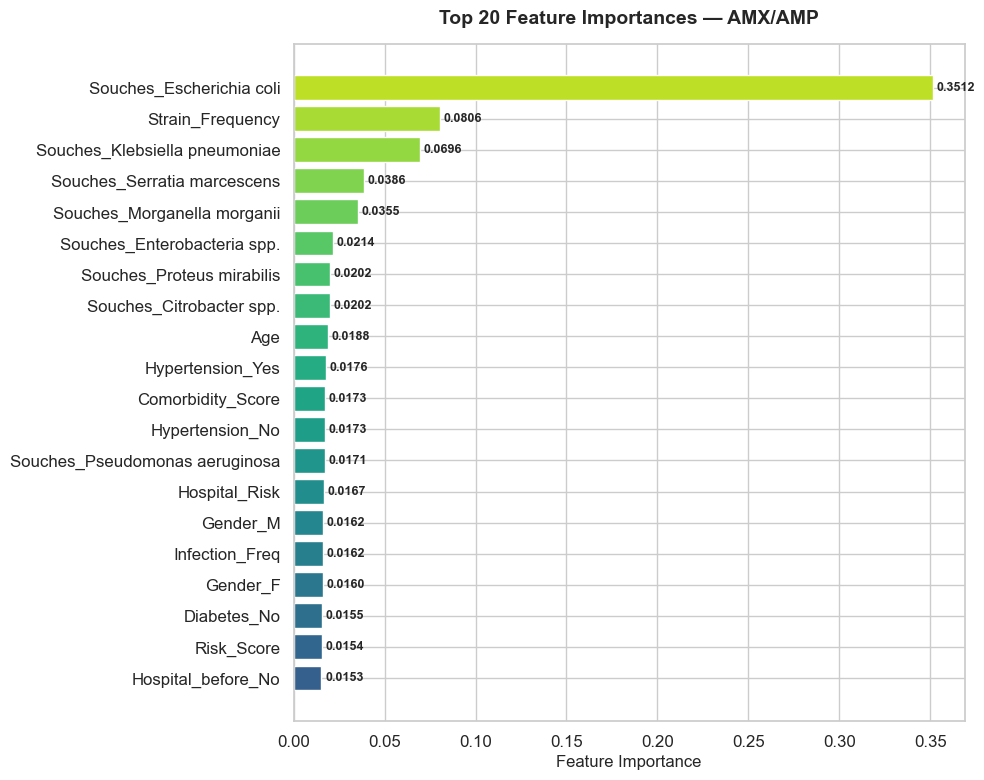

In [55]:
# ============================================================
# Feature Importance — Horizontal Bar Chart (Top 20)
# ============================================================
top_20 = importance_df.head(20).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Color gradient based on importance
colors = plt.cm.viridis(
    np.linspace(0.3, 0.9, len(top_20))
)

bars = ax.barh(
    top_20["Feature"],
    top_20["Importance"],
    color=colors,
    edgecolor="white",
    linewidth=1
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2.,
        f"{width:.4f}",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title(
    f"Top 20 Feature Importances — {TARGET}",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

---

## 15. Save Model & Metadata

We save two artifacts:

1. **`model_gen.joblib`** — The complete fitted sklearn Pipeline (preprocessor + XGBoost classifier). This can be loaded directly for inference without needing to refit.

2. **`gen_metadata.json`** — Metadata including the optimized threshold, metrics, feature list, and configuration. This allows the backend to apply the correct threshold during inference.

In [56]:
# ============================================================
# Save the trained pipeline
# ============================================================
model_filename = f"model_{TARGET.lower()}.joblib"

joblib.dump(pipeline, model_filename)

print(f"Model saved: {model_filename}")
print(f"File size: {pd.io.common.file_exists(model_filename)}")

FileNotFoundError: [Errno 2] No such file or directory: 'model_amx/amp.joblib'

In [ ]:
# ============================================================
# Save metadata (threshold + metrics)
# ============================================================
metadata = {
    "target": TARGET,
    "best_threshold": best_threshold,
    "best_f2_score": round(best_f2, 4),
    "roc_auc": round(roc_auc, 4),
    "default_threshold_metrics": {
        "precision": round(default_metrics["Precision"], 4),
        "recall": round(default_metrics["Recall"], 4),
        "f1": round(default_metrics["F1"], 4),
        "f2": round(default_metrics["F2"], 4)
    },
    "optimized_threshold_metrics": {
        "precision": round(optimized_metrics["Precision"], 4),
        "recall": round(optimized_metrics["Recall"], 4),
        "f1": round(optimized_metrics["F1"], 4),
        "f2": round(optimized_metrics["F2"], 4)
    },
    "features": features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "binary_features": binary_features,
    "model_params": {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": round(scale_pos_weight, 4)
    },
    "training_info": {
        "total_samples": total_samples,
        "train_size": len(X_train),
        "test_size": len(X_test),
        "resistant_count": resistant_count,
        "susceptible_count": suscept_count,
        "random_state": 42
    }
}

metadata_filename = f"{TARGET.lower()}_metadata.json"

with open(metadata_filename, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved: {metadata_filename}")
print()
print(json.dumps(metadata, indent=2))

---

## Summary

### Pipeline Complete

| Item | Value |
|---|---|
| **Target** | GEN (Gentamicin) |
| **Model** | XGBoost + ColumnTransformer Pipeline |
| **Class Imbalance** | Handled via `scale_pos_weight` |
| **Threshold** | F2-optimized (recall-weighted) |
| **Saved Model** | `model_gen.joblib` |
| **Saved Metadata** | `gen_metadata.json` |

### Next Steps
- Change `TARGET` to another antibiotic and re-run to train all 15 models
- Integrate the saved model and threshold into the FastAPI backend
- Compare performance across antibiotics to identify which targets need additional feature engineering or alternative model architectures